In [241]:
# ------------------------------------------------------------
# Cutthroat: A Topology Optimization Framework
# Author: John A. Gardiner
# ------------------------------------------------------------

# This code is part of the Cutthroat topology optimization framework, which is designed to optimize material distribution in heat exchangers for improved performance. The framework includes mesh generation, finite element analysis, and optimization algorithms. The following code snippet focuses on the simulation of meshes and the integration of a neural network for predicting optimal material distributions.

In [242]:
# -------------------------------------------------------------
# Libraries and Imports
# -------------------------------------------------------------

# Paths and File Handling
import os
import subprocess
from pathlib import Path
from jinja2 import Template
import json
import uuid
from dataclasses import dataclass, field, asdict
from typing import Optional
import gmsh

# Numerical and Visualization Libraries
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

# Neural Network and Machine Learning Libraries
import torch
import torch.nn as nn
from scipy.ndimage import label

In [243]:
# -------------------------------------------------------------
# Torch Device Configuration
# -------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU


In [244]:
@dataclass
class GeometryConfig:
    """
    Serializable snapshot of a heat exchanger geometry.
    
    Produced by the Generator and consumed by both the MeshGenerator (to build the .msh file)
    and the Optimizer (to map simulation results back onto the original grid).
    
    Fields:
    -------
    grid_nx, grid_ny: int
        Number of grid points in the x and y directions for the reference grid.
    domain_length, domain_height: float
        Physical dimensions of the rectangular fluid domain.
    occupancy_grid : list[list[float]]
        2D list representing the occupancy of the domain, where 0 indicates solid and 1 indicates fluid.Soft (0-1) CNN output before thresholding. Shape: (grid_ny, grid_nx).
        Stored so the CNN state can be reproduced exactly for the same geometry, and so the optimizer can use the same grid for mapping results back to the original geometry.
    obstacle_polygons : list[list[tuple[float, float]]]
        List of polygons representing the obstructions in the geometry. Each polygon is a list of (x, y) coordinates of its vertices.
    config_id : str
        UUID assigned at creation - ties a GeometryConfig to its .msh file and simulation results for reproducibility and traceability.
    """

    grid_nx: int
    grid_ny: int
    domain_length: float
    domain_height: float
    occupancy_grid: list # shape (grid_ny, grid_nx), values between 0 and 1
    obstacle_polygons: list # list of polygons, where each polygon is a list of (x, y) vertex coordinates
    config_id: str = field(default_factory=lambda: str(uuid.uuid4()))

    # Serialization
    def save(self, path: str | Path) -> None:
        """Save to a JSON file. Mesh files use the same config_id stem."""
        with open(path, "w") as f:
            json.dump(asdict(self), f, indent=2)
    
    @classmethod
    def load(cls, path: str | Path) -> "GeometryConfig":
        with open(path) as f:
            data = json.load(f)
        return cls(**data)
    
    @property
    def mesh_filename(self) -> str:
        """Canonical filename derived from config_id."""
        return f"hx_{self.config_id}.msh"
    
    def grid_cell_size(self) -> tuple[float, float]:
        """Physical size of each grid cell (dx, dy)."""
        return (self.domain_length / self.grid_nx, self.domain_height / self.grid_ny)
    
    def cell_center(self, ix: int, iy: int) -> tuple[float, float]:
        """
        Physical (x, y) coordinates of the center of grid cell (ix, iy).
        ix in [0, grid_nx), iy in [0, grid_ny).
        Origin is at the bottome left of the domain
        """
        dx, dy = self.grid_cell_size()
        x = (ix + 0.5) * dx
        y = (iy + 0.5) * dy - self.domain_height / 2
        return (x, y)

In [245]:
class HeatExchanger:
    """
    Contains the geometry, mesh, and simulation results for a single heat exchanger design. This is the main data structure that the Generator produces and the Optimizer consumes.

    Parameters:
    id: str
        Unique identifier for this heat exchanger design, typically derived from the GeometryConfig's config_id.
    config_filename: Optional[str]
        Path to the GeometryConfig JSON file that describes the geometry of this heat exchanger. This file is used to generate the mesh and to map simulation results back to the original grid.
    mesh_filename: Optional[str]
        Path to the GMSH .msh file that contains the mesh for this heat exchanger design. This file is generated from the GeometryConfig and is used as input for the simulation.
    result_filename: Optional[str]
        Path to the simulation results file (e.g., Exodus .e file) for this heat exchanger design. This file is generated by running the simulation on the mesh and contains the results that will be analyzed and used for optimization.
    geometry_config: Optional[GeometryConfig]
        An instance of GeometryConfig that describes the geometry of this heat exchanger. This is typically loaded from the config_filename and is used for reference throughout the optimization process.
    obstruction_polygons: Optional[list]
        A list of polygons representing the obstructions in the geometry, extracted from the occupancy grid. Each polygon is a list of (x, y) coordinates of its vertices. This is derived from the GeometryConfig and is used for mesh generation and visualization.
    solved: bool
        A flag indicating whether the simulation for this heat exchanger design has been run and results are available. This is used to track the state of the optimization process.
    results: Optional[dict]
        A dictionary containing the analyzed results from the simulation, such as temperature distribution, flow patterns, and performance metrics. This is derived from the result_filename and is used for optimization and decision-making.
    """
    
    def __init__(
        self,
        id: str,
        mesh_params: dict,
        geometry_config: Optional[GeometryConfig] = None,
    ):
        self.id = id
        self.mesh_params = mesh_params
        self.config_filename = None
        self.mesh_filename = None
        self.result_filename = None
        self.set_filenames()
        
        # Load geometry config and extract obstruction polygons
        self.geometry_config = geometry_config
        self.obstruction_polygons = None
        if geometry_config is None:
            self.load_geometry_config()
        else:
            self.obstruction_polygons = self.geometry_config.obstacle_polygons

        # Check for existing mesh and results
        self.mesh_exists = self.check_for_mesh()
        
        # Simulation state
        self.results = None
        self.solved = self.check_for_existing_results()
    
    def set_filenames(self):
        """Set the mesh_filename and result_filename based on the heat exchanger ID."""
        self.config_filename = f"configs/hx_{self.id}.json"
        self.mesh_filename = f"meshes/hx_{self.id}.msh"
        self.result_filename = f"results/hx_{self.id}.e"

    def load_geometry_config(self):
        """Load the GeometryConfig from the config_filename."""
        self.geometry_config = GeometryConfig.load(self.config_filename)
        self.obstruction_polygons = self.geometry_config.obstacle_polygons

    def check_for_mesh(self) -> bool:
        """Check if the mesh file already exists for this heat exchanger design."""
        if os.path.exists(self.mesh_filename):
            return True
        else:
            self.generate_mesh()
        return os.path.exists(self.mesh_filename)

    def check_for_existing_results(self) -> bool:
        """Check if the result file already exists for this heat exchanger design."""
        if os.path.exists(self.result_filename):
            self.read_results()
        return os.path.exists(self.result_filename)
    
    def read_results(self):
        """Read the simulation results from the result_filename and store them in self.results."""
        # Placeholder for reading results - this would depend on the format of the results file
        self.results = None

    def create_custom_obstruction(self, points: list[tuple[float, float]]) -> int:
        """
        Create a planar surface in GMSH from an ordered list of (x, y) points.
        Returns the GMSH surface tag.
        """
        n_points = len(points)
        gmsh_points = []
        for coord in points:
            pt = gmsh.model.occ.addPoint(coord[0], coord[1], 0)
            gmsh_points.append(pt)
 
        lines = []
        for i in range(n_points):
            line = gmsh.model.occ.addLine(
                gmsh_points[i],
                gmsh_points[(i + 1) % n_points],
            )
            lines.append(line)
 
        cl = gmsh.model.occ.addCurveLoop(lines)
        surface = gmsh.model.occ.addPlaneSurface([cl])
        return surface

    def generate_mesh(self) -> str:
        """
        Returns the path to the written .msh file.
        """
        gmsh.initialize()
        gmsh.model.add(f"hx_{self.id}")
 
        rect = gmsh.model.occ.addRectangle(
            0, 0, 0,
            self.geometry_config.domain_length, self.geometry_config.domain_height,
        )
        gmsh.model.occ.synchronize()
 
        obstructions = []
        for polygon in self.obstruction_polygons:
            surface = self.create_custom_obstruction(polygon)
            obstructions.append(surface)
        gmsh.model.occ.synchronize()
 
        if obstructions:
            cut = gmsh.model.occ.cut(
                [(2, rect)],
                [(2, s) for s in obstructions],
                removeObject=True,
                removeTool=True,
            )
            gmsh.model.occ.synchronize()
            out_dim_tags, _ = cut
            fluid_surfaces = [tag for dim, tag in out_dim_tags if dim == 2]
        else:
            # No obstacles — entire rectangle is the fluid domain
            fluid_surfaces = [rect]
 
        if not fluid_surfaces:
            gmsh.finalize()
            raise RuntimeError(
                "Boolean cut produced no fluid domain. "
                "Check that obstacles don't fill the entire domain."
            )
 
        gmsh.model.addPhysicalGroup(2, fluid_surfaces, name="Fluid")

        # Boundary classification
        gmsh.model.occ.synchronize()
        boundaries = gmsh.model.getBoundary(
            [(2, s) for s in fluid_surfaces], oriented=False
        )
 
        wall_curves, inlet, outlet, top, bottom = [], [], [], [], []
        for dim, tag in boundaries:
            x, y, _ = gmsh.model.occ.getCenterOfMass(dim, tag)
            if abs(x) < 1e-6:
                inlet.append(tag)
            elif abs(x - self.geometry_config.domain_length) < 1e-6:
                outlet.append(tag)
            elif abs(y - self.geometry_config.domain_height / 2) < 1e-6:
                top.append(tag)
            elif abs(y + self.geometry_config.domain_height / 2) < 1e-6:
                bottom.append(tag)
            else:
                wall_curves.append(tag)
 
        if wall_curves:
            gmsh.model.addPhysicalGroup(1, wall_curves, name="Wall")
        if inlet:
            gmsh.model.addPhysicalGroup(1, inlet, name="Inlet")
        if outlet:
            gmsh.model.addPhysicalGroup(1, outlet, name="Outlet")
        if top:
            gmsh.model.addPhysicalGroup(1, top, name="Top")
        if bottom:
            gmsh.model.addPhysicalGroup(1, bottom, name="Bottom")
 
        p = self.mesh_params
        gmsh.option.setNumber("Mesh.CharacteristicLengthMin", p["mesh_min"])
        gmsh.option.setNumber("Mesh.CharacteristicLengthMax", p["mesh_max"])
        gmsh.option.setNumber("Mesh.Algorithm",               p["mesh_algorithm"])
        gmsh.option.setNumber("Mesh.RecombineAll",             p["mesh_recombine"])
        gmsh.option.setNumber("Mesh.ElementOrder",             p["mesh_element_order"])
 
        gmsh.model.mesh.generate(2)
        gmsh.write(self.mesh_filename)
        gmsh.finalize()

        return self.mesh_filename

In [246]:
class RandomNoiseGenerator(nn.Module):
    """
    Bootstrapping replacement for HeatExchangerCNN.
    
    Produces occupancy grids that reliably pass the GeometryFilter by
    construction, without requiring any training. The approach is to place
    a random number of rectangular solid blobs on the grid, sized and
    positioned to avoid fully blocking the flow path.
    
    This is a drop-in replacement for the CNN during pipeline development.
    Once the simulator is producing reward signals, swap this out for a
    trained HeatExchangerCNN without changing anything else.

    Parameters
    ----------
    grid_nx, grid_ny : int
        Grid dimensions, must match the rest of the pipeline.
    min_density, max_density : float
        Target solid fraction range — should match your GeometryFilter bounds.
    n_blobs_range : tuple[int, int]
        Min and max number of rectangular solid blobs to place.
    max_blob_height_frac : float
        Maximum blob height as a fraction of grid_ny. Capped below 1.0 to
        ensure blobs never fully block the flow path vertically.
    """

    def __init__(
        self,
        grid_nx: int = 200,
        grid_ny: int = 40,
        min_density: float = 0.15,
        max_density: float = 0.80,
        n_blobs_range: tuple = (5, 40),
        max_blob_height_frac: float = 0.7,
    ):
        super().__init__()
        self.grid_nx = grid_nx
        self.grid_ny = grid_ny
        self.min_density = min_density
        self.max_density = max_density
        self.n_blobs_range = n_blobs_range
        # Cap at 0.85 regardless of input — a blob taller than 85% of the
        # domain will almost always block the flow path
        self.max_blob_height_frac = min(max_blob_height_frac, 0.85)

    def __call__(self, z: torch.Tensor) -> torch.Tensor:
        """
        Mimics the CNN's forward() signature: accepts a latent tensor,
        returns a soft occupancy tensor of shape (1, 1, grid_ny, grid_nx).
        
        The latent vector z is used to seed numpy's RNG so the same z
        always produces the same geometry, which matters for reproducibility
        during RL training later.
        """
        # Seed from z so generation is deterministic for a given latent vector
        seed = int(z.abs().sum().item() * 1e6) % (2**31)
        rng = np.random.default_rng(seed)

        target_density = rng.uniform(self.min_density, self.max_density)
        grid = self._place_blobs(rng, target_density)

        # Convert binary grid to soft values (0.1 for fluid, 0.9 for solid)
        # so it behaves like a sigmoid output and threshold=0.5 works cleanly
        soft = np.where(grid, 0.9, 0.1).astype(np.float32)

        return torch.tensor(soft).unsqueeze(0).unsqueeze(0)  # (1, 1, grid_ny, grid_nx)

    def _place_blobs(self, rng: np.random.Generator, target_density: float) -> np.ndarray:
        """
        Place rectangular blobs on an empty grid until target solid density
        is approximately reached. Blobs are placed in the interior only —
        never touching the left or right columns — so the flow path check
        always passes trivially (inlet and outlet columns are always fluid).
        """
        grid = np.zeros((self.grid_ny, self.grid_nx), dtype=bool)

        max_blob_h = max(1, int(self.grid_ny * self.max_blob_height_frac))
        # Leave at least 1-cell gap at inlet (col 0) and outlet (col -1)
        x_min, x_max = 1, self.grid_nx - 2

        n_blobs = rng.integers(*self.n_blobs_range)
        total_cells = self.grid_ny * self.grid_nx

        for _ in range(n_blobs):
            if grid.mean() >= target_density:
                break

            # Random blob dimensions
            blob_h = rng.integers(1, max_blob_h + 1)
            blob_w = rng.integers(1, (self.grid_nx // 4) + 1)

            # Random position (fully within interior)
            y0 = rng.integers(0, self.grid_ny - blob_h + 1)
            x0 = rng.integers(x_min, x_max - blob_w + 1)

            grid[y0:y0 + blob_h, x0:x0 + blob_w] = True

        return grid

In [247]:
class HeatExchangerCNN(nn.Module):
    """
    Maps a latent vector z -> occupancy grid of shape (1, grid_ny, grid_nx).

    The output is passed through sigmoid so values are in (0, 1).
    During training, keep the soft output for RL policy log-probs.
    For geometry generation, threshold at 'threshold' to get binary cells,
    then extract connected blobs as obstacle polygons.

    Architecture: fully-connected projection -> reshape -> series of 
    transposed conv upsampling blocks. The final spatial size is determined by grid_nx and grid_ny
    - the network is built to match these exactly.    
    """

    def __init__(
            self,
            latent_dim: int = 32,
            grid_nx: int = 20,
            grid_ny: int = 10,
            base_channels: int = 64,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.grid_nx = grid_nx
        self.grid_ny = grid_ny
        self.base_channels = base_channels

        # Project z to a small spatial feature map, then upsample.
        # We start at (base_channels, 2, 2) and double the spatial dims each block.
        # Number of upsampling blocks needed:
        self._n_ups_x = int(np.ceil(np.log2(grid_nx))) - 1 # number of doublings needed
        self._n_ups_y = int(np.ceil(np.log2(grid_ny))) - 1
        n_blocks = max(self._n_ups_x, self._n_ups_y)

        # FC projection
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 4),
            nn.ReLU(),
            nn.Linear(base_channels * 4, base_channels * 2 * 2),
            nn.ReLU()
        )
        self.init_channels = base_channels
        self.init_h = 2
        self.init_w = 2

        # Upsampling blocks
        blocks = []
        in_ch = base_channels
        for i in range(n_blocks):
            out_ch = max(in_ch // 2, 8)
            blocks.append(nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            ))
            in_ch = out_ch
        self.ups = nn.ModuleList(blocks)

        # Final 1x1 conv to singe-channel occupancy grid
        self.head = nn.Conv2d(in_ch, 1, kernel_size=1)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Parameters:
        z: Tensor of shape (B, latent_dim)
        
        Returns: 
        Tensor of shape (B, 1, grid_ny, grid_nx) occupancy grid with values in (0, 1)
        """
        B = z.shape[0]
        x = self.fc(z) # (B, base_channels * 2 * 2)
        x = x.view(B, self.init_channels, self.init_h, self.init_w) # (B, base_channels, 2, 2)

        for up in self.ups:
            x = up(x) # upsample
        x = self.head(x) # (B, 1, H, W)
        
        # Crop or interpolate to extract target size
        x = torch.nn.functional.interpolate(
            x, size=(self.grid_ny, self.grid_nx), mode='bilinear', align_corners=False
            )
        x = torch.sigmoid(x) # values in (0, 1)
        return x

In [248]:
class PretrainEarlyStopping:
    """
    Stops pretraining when either of two conditions is met:

    1. Loss plateau: total loss hasn't improved by more than `min_delta`
       for `patience` consecutive log intervals. Standard early stopping.

    2. Diversity collapse: the mean inter-sample std across the batch
       drops below `collapse_std_threshold` for `collapse_patience`
       consecutive checks. This catches mode collapse even if the loss
       is still technically decreasing (because the validity terms are
       happy but diversity has gone to zero).

    Parameters
    ----------
    patience : int
        Log intervals without loss improvement before stopping.
    min_delta : float
        Minimum improvement in total loss to count as progress.
    collapse_std_threshold : float
        Inter-sample std below this triggers collapse detection.
        Should be lower than diversity_min_std in FilterLoss —
        this is a last-resort catch, not the primary diversity signal.
    collapse_patience : int
        Consecutive checks below threshold before stopping.
    """

    def __init__(
        self,
        patience: int = 10,
        min_delta: float = 1e-4,
        collapse_std_threshold: float = 0.05,
        collapse_patience: int = 5,
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.collapse_std_threshold = collapse_std_threshold
        self.collapse_patience = collapse_patience

        self.best_loss = float("inf")
        self.steps_without_improvement = 0
        self.consecutive_collapse_checks = 0
        self.stop_reason = None

    @property
    def should_stop(self) -> bool:
        return self.stop_reason is not None

    def update(self, total_loss: float, soft_grid: torch.Tensor) -> bool:
        """
        Call once per log interval. Returns True if training should stop.

        Parameters
        ----------
        total_loss : float
        soft_grid : Tensor of shape (B, 1, grid_ny, grid_nx)
            The most recent batch output, used for collapse detection.
        """
        # Check 1: loss plateau
        if total_loss < self.best_loss - self.min_delta:
            self.best_loss = total_loss
            self.steps_without_improvement = 0
        else:
            self.steps_without_improvement += 1
            if self.steps_without_improvement >= self.patience:
                self.stop_reason = (
                    f"Loss plateaued for {self.patience} intervals "
                    f"(best={self.best_loss:.4f})"
                )
                return True

        # Check 2: diversity collapse
        if soft_grid.shape[0] > 1:
            inter_sample_std = soft_grid.std(dim=0).mean().item()
            if inter_sample_std < self.collapse_std_threshold:
                self.consecutive_collapse_checks += 1
                if self.consecutive_collapse_checks >= self.collapse_patience:
                    self.stop_reason = (
                        f"Mode collapse detected: inter-sample std "
                        f"{inter_sample_std:.4f} < {self.collapse_std_threshold} "
                        f"for {self.collapse_patience} consecutive checks"
                    )
                    return True
            else:
                self.consecutive_collapse_checks = 0

        return False

In [1021]:
class GeometryFilter:
    """
    Validates an occupancy grid before committing to mesh generation.

    Checks
    ------
    1. Solid density: fraction of solid cells must be within [min_density, max_density].
    2. Flow path: at least one continuous fluid path from inlet (left) to outlet (right).
    3. No enclosed fluid: every fluid region must connect to at least one domain boundary
       (top, bottom, left, or right column). Fluid pockets fully surrounded by solid
       are rejected.

    Parameters
    ----------
    min_density, max_density : float
        Solid fraction bounds.
    threshold : float
        Binarization threshold, should match HeatExchangerGenerator.
    """

    def __init__(
        self,
        min_density: float = 0.10,
        max_density: float = 0.75,
        threshold: float = 0.5,
    ):
        self.min_density = min_density
        self.max_density = max_density
        self.threshold = threshold

    def is_valid(self, occupancy: np.ndarray) -> tuple[bool, dict]:
        binary = (occupancy >= self.threshold)

        density_ok, density_val = self._check_density(binary)
        flow_ok                 = self._check_flow_path(binary)
        no_pockets              = self._check_no_enclosed_fluid(binary)

        report = {
            "solid_density":      round(float(density_val), 4),
            "density_ok":         density_ok,
            "has_flow_path":      flow_ok,
            "no_enclosed_fluid":  no_pockets,
            "valid":              density_ok and flow_ok and no_pockets,
        }
        return report["valid"], report

    def _check_density(self, binary: np.ndarray) -> tuple[bool, float]:
        density = binary.mean()
        return self.min_density <= density <= self.max_density, density

    def _check_flow_path(self, binary: np.ndarray) -> bool:
        fluid = ~binary
        if not fluid[:, 0].any() or not fluid[:, -1].any():
            return False
        labeled, n = label(fluid, structure=np.array([[0,1,0],[1,1,1],[0,1,0]]))
        for comp_id in range(1, n + 1):
            region = labeled == comp_id
            if region[:, 0].any() and region[:, -1].any():
                return True
        return False

    def _check_no_enclosed_fluid(self, binary: np.ndarray) -> bool:
        """
        Check that no fluid region is fully enclosed by solid.

        A fluid region is considered enclosed if it does not touch any of
        the four domain boundaries (top row, bottom row, left column, right
        column). Touching any boundary means the fluid is reachable from
        outside the heat exchanger, which is the physical requirement.
        """
        fluid = ~binary
        labeled, n = label(fluid, structure=np.array([[0,1,0],[1,1,1],[0,1,0]]))
        for comp_id in range(1, n + 1):
            region = labeled == comp_id
            touches_boundary = (
                region[:, 0].any()   and   # left column (inlet)
                region[:, -1].any()       # right column (outlet)
            )
            if not touches_boundary:
                return False
        return True

In [1040]:
class FilterLoss(nn.Module):
    """
    Differentiable proxy for all three GeometryFilter checks.

    Parameters
    ----------
    min_density, max_density : float
        Target solid fraction bounds.
    density_weight : float
        Weight for the density loss term.
    flow_weight : float
        Weight for the flow path loss term.
    pocket_weight : float
        Weight for the enclosed fluid loss term.
    """

    def __init__(
        self,
        min_density: float = 0.20,
        max_density: float = 0.80,
        density_weight: float = 2.5, # increase to more strongly penalize densities outside the valid range
        flow_weight: float = 2.0, # increase to strongly encourage a clear flow path
        pocket_weight: float = 14.0, # enclosed fluid is a hard fail, increase to punish it more heavily
        diversity_weight: float = 2.0, # increase to encourage more diversity in the batches
        diversity_min_std: float = 0.25,
        tortuosity_weight: float = 0.0, # encourage tortuosity to break up straight channels that can cause periodic patterns
        min_tortuosity: float = 0.05, 
        fragmentation_weight: float = 2.0, # increase to discourage large blocks of solid or fluid — encourages more, smaller channels
        channel_scale_weight: float = 4.0, # increase to encourage fine structure
        target_channel_width: float = 0.3, # pushes toward finer features
        interface_weight: float = 4.5, # increase to encourage sharper solid-fluid interfaces
        periodicity_weight: float = 0.25, # increase to discourage periodic patterns 
    ):
        super().__init__()
        self.min_density = min_density
        self.max_density = max_density
        self.density_weight = density_weight
        self.flow_weight = flow_weight
        self.pocket_weight = pocket_weight
        self.diversity_weight = diversity_weight
        self.diversity_min_std = diversity_min_std
        self.tortuosity_weight = tortuosity_weight
        self.min_tortuosity = min_tortuosity
        self.fragmentation_weight = fragmentation_weight
        self.channel_scale_weight = channel_scale_weight
        self.target_channel_width = target_channel_width
        self.interface_weight = interface_weight
        self.periodicity_weight = periodicity_weight

    def forward(self, soft_grid):
        density_loss    = self._density_loss(soft_grid)
        flow_loss       = self._flow_loss(soft_grid)
        pocket_loss     = self._pocket_loss(soft_grid)
        diversity_loss  = self._diversity_loss(soft_grid, self.diversity_min_std)
        tortuosity_loss = self._tortuosity_loss(soft_grid, self.min_tortuosity)
        fragmentation_loss = self._fragmentation_loss(soft_grid)
        channel_scale_loss = self._channel_scale_loss(soft_grid, self.target_channel_width)
        interface_loss = self._interface_loss(soft_grid)
        periodicity_loss = self._periodicity_loss(soft_grid)

        total = (
            self.density_weight    * density_loss    +
            self.flow_weight       * flow_loss       +
            self.pocket_weight     * pocket_loss     +
            self.diversity_weight  * diversity_loss  +
            self.tortuosity_weight * tortuosity_loss +
            self.fragmentation_weight * fragmentation_loss +
            self.channel_scale_weight * channel_scale_loss +
            self.interface_weight * interface_loss +
            self.periodicity_weight * periodicity_loss
        )
        breakdown = {
            "density_loss":    density_loss.item(),
            "flow_loss":       flow_loss.item(),
            "pocket_loss":     pocket_loss.item(),
            "diversity_loss":  diversity_loss.item(),
            "tortuosity_loss": tortuosity_loss.item(),
            "fragmentation_loss": fragmentation_loss.item(),
            "channel_scale_loss": channel_scale_loss.item(),
            "interface_loss": interface_loss.item(),
            "periodicity_loss": periodicity_loss.item(),
            "total_loss":      total.item(),
        }
        return total, breakdown

    def _density_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Two-level density penalty:
        1. Soft density (pre-threshold): squared hinge + direct pull toward
        target midpoint. Same as before — provides gradient during training.
        2. Hard density (post-threshold, straight-through estimator): checks
        the binarized grid density against the valid range. Uses stop-gradient
        on the binary step so the backward pass still flows through the soft
        values, but the loss value itself reflects what the filter will see.
        """
        # --- Soft penalty (differentiable) ---
        density_soft = soft_grid.mean(dim=[1, 2, 3])    # (B,)

        too_low_soft  = torch.relu(self.min_density - density_soft) ** 2
        too_high_soft = torch.relu(density_soft - self.max_density) ** 2
        hinge_loss = (too_low_soft + too_high_soft).mean()

        target = (self.min_density + self.max_density) / 2.0
        pull_loss = (torch.relu(self.min_density - density_soft)
                    * torch.abs(density_soft - target)).mean()

        # --- Hard penalty (straight-through estimator) ---
        # Forward: use binarized density so the loss value matches filter reality.
        # Backward: gradient flows through soft_grid as if no threshold was applied.
        binary = (soft_grid >= 0.5).float()
        binary_ste = soft_grid + (binary - soft_grid).detach()
        density_hard = binary_ste.mean(dim=[1, 2, 3])   # (B,)

        too_low_hard  = torch.relu(self.min_density - density_hard) ** 2
        too_high_hard = torch.relu(density_hard - self.max_density) ** 2
        hard_loss = (too_low_hard + too_high_hard).mean()

        return hinge_loss + pull_loss + hard_loss

    def _flow_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Switched to isotropic 3x3 kernel to remove horizontal stripe bias.
        The horizontal kernel was the direct cause of the repeating vertical
        column pattern — stripes of solid separated by single fluid columns
        score perfectly on horizontal continuity.
        """
        fluid = 1.0 - soft_grid

        inlet_blocking  = (1.0 - fluid[:, :, :, 0]).mean()
        outlet_blocking = (1.0 - fluid[:, :, :, -1]).mean()
        column_loss = inlet_blocking + outlet_blocking

        # Isotropic kernel — no directional bias
        kernel = torch.ones(1, 1, 3, 3, device=soft_grid.device) / 9.0
        neighbor_fluid = torch.nn.functional.conv2d(fluid, kernel, padding=1)
        connectivity_loss = torch.relu(fluid - neighbor_fluid).mean()

        return column_loss + connectivity_loss
    
    '''def _flow_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        fluid = 1.0 - soft_grid

        inlet_blocking  = (1.0 - fluid[:, :, :, 0]).mean()
        outlet_blocking = (1.0 - fluid[:, :, :, -1]).mean()
        column_loss = inlet_blocking + outlet_blocking

        kernel = torch.ones(1, 1, 1, 3, device=soft_grid.device)
        horizontal_continuity = torch.nn.functional.conv2d(
            fluid, kernel, padding=(0, 1)
        ) / 3.0
        connectivity_loss = torch.relu(fluid - horizontal_continuity).mean()

        return column_loss + connectivity_loss'''

    def _pocket_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Penalizes fluid cells that are isolated from the domain boundary.

        Strategy: a fluid cell that is far from any boundary is likely
        part of an enclosed pocket. We approximate boundary connectivity
        using a distance-weighted penalty — fluid cells near the center
        of a solid cluster are penalized more than those near an edge.

        This is done in two steps:
        1. Compute a "boundary proximity" map: cells near any domain edge
           get high values, interior cells get low values.
        2. Penalize fluid cells (high soft_grid = solid, so low fluid value)
           that have low boundary proximity AND are surrounded by solid.
        """
        fluid = 1.0 - soft_grid  # (B, 1, grid_ny, grid_nx)
        B, _, H, W = fluid.shape

        # Build boundary proximity map — 1.0 at edges, decaying inward.
        # Uses the minimum normalized distance to any of the four edges.
        device = soft_grid.device
        y_idx = torch.arange(H, device=device).float()
        x_idx = torch.arange(W, device=device).float()

        dist_top    = y_idx / (H - 1)           # 0 at top row, 1 at bottom
        dist_bottom = 1.0 - dist_top             # 0 at bottom row, 1 at top
        dist_left   = x_idx / (W - 1)           # 0 at left col, 1 at right
        dist_right  = 1.0 - dist_left            # 0 at right col, 1 at left

        # Proximity = 1 at boundary, 0 at maximum interior distance
        proximity = torch.minimum(
            torch.minimum(dist_top.unsqueeze(1), dist_bottom.unsqueeze(1)),
            torch.minimum(dist_left.unsqueeze(0), dist_right.unsqueeze(0))
        )  # (H, W)
        # Invert: high value = far from boundary = interior
        interior_weight = (1.0 - proximity).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)

        # Penalize fluid cells in the interior that are surrounded by solid.
        # A fluid cell surrounded by solid will have low average neighbor fluid value.
        kernel = torch.ones(1, 1, 3, 3, device=device) / 9.0
        neighbor_fluid = torch.nn.functional.conv2d(fluid, kernel, padding=1)

        # Isolated fluid = fluid cell with low fluid neighbors = likely a pocket
        isolated = fluid * torch.relu(0.5 - neighbor_fluid)

        # Weight by interior distance so boundary-adjacent fluid isn't penalized
        pocket_penalty = (isolated * interior_weight).mean()

        return pocket_penalty
    
    def _diversity_loss(
        self,
        soft_grid: torch.Tensor,
        min_std: float = 0.15,
    ) -> torch.Tensor:
        """
        Penalizes mode collapse by encouraging two kinds of diversity:

        1. Spatial variance within each sample — the occupancy values should
        vary across the grid, not be uniform. A collapsed CNN produces
        nearly identical values everywhere (e.g. all ~0.5), giving near-zero
        spatial std. We penalize when per-sample std drops below min_std.

        2. Inter-sample variance across the batch — different latent vectors
        should produce different grids. If all samples in a batch look the
        same, the mean of the batch looks like any individual sample, so the
        std across samples is near zero. We penalize that too.

        Parameters
        ----------
        soft_grid : Tensor of shape (B, 1, grid_ny, grid_nx)
        min_std : float
            Minimum acceptable std. Values below this are penalized.
            0.15 is a reasonable starting point — pure noise has std ~0.29,
            a fully collapsed output has std ~0.0.
        """
        # 1. Spatial variance: std across spatial dims for each sample
        spatial_std = soft_grid.std(dim=[2, 3])          # (B, 1)
        spatial_loss = torch.relu(min_std - spatial_std).mean()

        # 2. Inter-sample variance: std across batch dim at each spatial location
        if soft_grid.shape[0] > 1:
            batch_std = soft_grid.std(dim=0)             # (1, grid_ny, grid_nx)
            batch_loss = torch.relu(min_std - batch_std).mean()
        else:
            batch_loss = torch.tensor(0.0, device=soft_grid.device)

        return spatial_loss + batch_loss

    def _tortuosity_loss(
        self,
        soft_grid: torch.Tensor,
        min_tortuosity: float = 0.3,
    ) -> torch.Tensor:
        """
        Penalizes designs where fluid flows too directly from inlet to outlet.

        Tortuosity is approximated by measuring vertical variation in the
        fluid distribution across x-slices. A straight horizontal channel
        has the same fluid pattern at every x position (low variation).
        A snaking channel shifts up and down across x positions (high variation).

        Specifically: for each x column, compute the center of mass of the
        fluid cells in y. A path that snakes will have a y center-of-mass
        that varies significantly across x. We penalize when that variation
        is below min_tortuosity.

        Parameters
        ----------
        min_tortuosity : float
            Minimum acceptable std of the fluid y-centroid across x columns.
            Normalized to [0, 1] by grid height. 0.3 means the centroid
            should shift by at least 30% of the domain height across the length.
        """
        fluid = 1.0 - soft_grid  # (B, 1, grid_ny, grid_nx)
        B, _, H, W = fluid.shape

        # y coordinate for each row, normalized to [0, 1]
        y_coords = torch.linspace(0, 1, H, device=soft_grid.device)
        y_coords = y_coords.view(1, 1, H, 1).expand(B, 1, H, W)

        # Fluid-weighted y centroid at each x column: (B, 1, W)
        fluid_sum = fluid.sum(dim=2) + 1e-6          # avoid div by zero
        y_centroid = (fluid * y_coords).sum(dim=2) / fluid_sum  # (B, 1, W)

        # Std of the centroid across x — high for snaking, low for straight
        tortuosity = y_centroid.std(dim=2)           # (B, 1)

        # Penalize when tortuosity is below the minimum
        tortuosity_loss = torch.relu(min_tortuosity - tortuosity).mean()
        return tortuosity_loss
    
    
    def _channel_scale_loss(
        self,
        soft_grid: torch.Tensor,
        target_channel_width: float = 0.05,
    ) -> torch.Tensor:
        """
        Encourages thin horizontally-oriented channels by rewarding two
        specific spectral characteristics:

        1. Aspect ratio bias: energy should be concentrated at higher
        frequencies along y (short axis) than along x (long axis).
        Horizontal channels have high y-frequency content (thin vertically)
        but lower x-frequency content (long horizontally). We enforce this
        by penalizing when y-frequency energy is lower than x-frequency energy.

        2. Mid-frequency target: penalize when energy is dominated by either
        very low frequencies (large blobs) or very high frequencies (single
        pixel noise / the four-square artifact). Target a mid-frequency band
        corresponding to the desired channel width.

        Normalization fix: divide power spectrum by its own sum rather than
        comparing region means to total mean. This makes the loss scale-invariant
        with respect to grid size and absolute activation magnitude, keeping
        values in [0, 1] regardless of H and W.
        """
        solid = soft_grid.squeeze(1)        # (B, H, W)
        B, H, W = solid.shape

        fft = torch.fft.rfft2(solid)
        power = fft.abs() ** 2              # (B, H, W//2+1)

        # Normalize by total power so all values are fractions summing to 1.
        # This is the key fix for the large magnitude issue.
        total_power = power.sum(dim=[1, 2], keepdim=True) + 1e-8
        power_norm = power / total_power    # (B, H, W//2+1), sums to ~1 per sample

        # --- Term 1: aspect ratio bias ---
        # 1D power spectra along each axis (marginalize over the other)
        power_x = power_norm.mean(dim=1)    # (B, W//2+1) — variation along x
        power_y = power_norm.mean(dim=2)    # (B, H)      — variation along y

        # Frequency index corresponding to target_channel_width
        target_freq_x = max(1, int(W * target_channel_width))
        target_freq_y = max(1, int(H * target_channel_width))

        # Energy above target frequency (high freq = fine structure)
        high_freq_x = power_x[:, target_freq_x:].sum(dim=1)   # (B,)
        high_freq_y = power_y[:, target_freq_y:].sum(dim=1)   # (B,)

        # Horizontal channels: more high-freq energy in y than x.
        # Penalize when y high-freq energy is less than x high-freq energy.
        aspect_loss = torch.relu(high_freq_x - high_freq_y).mean()

        # --- Term 2: mid-frequency target ---
        # Define three bands along y: low, mid, high
        low_end  = max(1, int(H * 0.05))
        high_start = max(low_end + 1, int(H * 0.40))

        low_band_y  = power_y[:, 1:low_end].sum(dim=1)           # (B,) DC excluded
        mid_band_y  = power_y[:, low_end:high_start].sum(dim=1)  # (B,)
        high_band_y = power_y[:, high_start:].sum(dim=1)         # (B,)

        # Penalize when low or high band dominates over mid band
        # Low dominance = large blobs; high dominance = pixel noise / four squares
        mid_dominance_loss = (
            torch.relu(low_band_y  - mid_band_y) +
            torch.relu(high_band_y - mid_band_y)
        ).mean()

        return aspect_loss + mid_dominance_loss
    
    def _fragmentation_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Combined solid and fluid fragmentation loss.

        Replaces the separate _solid_fragmentation_loss and _fluid_fragmentation_loss.
        Both had the same structure but applied to solid and fluid grids respectively,
        so combining them removes the weight imbalance between the two and makes
        tuning simpler — one weight controls the solid/fluid structural balance together.

        Penalizes:
        - Columns where solid blocks the full height (vertical_blockage)
        - Rows where fluid spans the full width (horizontal_openness)
        - Unimodal solid marginal distributions (one large solid blob)
        - Unimodal fluid marginal distributions (one large open space)

        The cross-symmetry between solid and fluid terms means neither phase
        can dominate spatially, which naturally pushes toward interleaved structure.
        """
        solid = soft_grid                   # (B, 1, H, W)
        fluid = 1.0 - soft_grid
        B, _, H, W = solid.shape

        # --- Solid terms ---
        # Penalize columns that are solid all the way through vertically
        col_min_solid = solid.min(dim=2).values           # (B, 1, W)
        vertical_blockage = col_min_solid.mean()

        solid_flat = solid.squeeze(1)                     # (B, H, W)
        solid_y_marginal = solid_flat.mean(dim=2)         # (B, H)
        solid_x_marginal = solid_flat.mean(dim=1)         # (B, W)
        solid_y_var = solid_y_marginal.var(dim=1)         # (B,)
        solid_x_var = solid_x_marginal.var(dim=1)         # (B,)

        min_var = 0.02
        solid_compactness = (
            torch.relu(min_var - solid_y_var) +
            torch.relu(min_var - solid_x_var)
        ).mean()

        # --- Fluid terms ---
        # Penalize rows that are fluid all the way through horizontally
        row_min_fluid = fluid.min(dim=3).values           # (B, 1, H)
        horizontal_openness = row_min_fluid.mean()

        fluid_flat = fluid.squeeze(1)                     # (B, H, W)
        fluid_y_marginal = fluid_flat.mean(dim=2)         # (B, H)
        fluid_x_marginal = fluid_flat.mean(dim=1)         # (B, W)
        fluid_y_var = fluid_y_marginal.var(dim=1)         # (B,)
        fluid_x_var = fluid_x_marginal.var(dim=1)         # (B,)

        fluid_compactness = (
            torch.relu(min_var - fluid_y_var) +
            torch.relu(min_var - fluid_x_var)
        ).mean()

        # --- Balance term ---
        # Penalize when solid and fluid span penalties are asymmetric.
        # If vertical_blockage >> horizontal_openness the design has tall solid blobs.
        # If horizontal_openness >> vertical_blockage it has wide fluid corridors.
        # We want them roughly equal, which corresponds to isotropic interleaving.
        balance_loss = (vertical_blockage - horizontal_openness).abs()

        return (
            vertical_blockage  +
            horizontal_openness +
            solid_compactness  +
            fluid_compactness  +
            balance_loss
        )

    def _interface_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Rewards high solid-fluid interface density throughout the domain.

        A design with many snaking channels through a solid matrix has a very
        high perimeter-to-area ratio — lots of solid-fluid boundaries. A design
        with a few large blobs or a few wide channels has low interface density.
        This term directly rewards the kind of fine, interleaved structure you want.

        Computed using Sobel-like finite differences on the soft grid — regions
        where the gradient magnitude is high are solid-fluid boundaries.
        We reward high mean gradient magnitude across the domain.

        Additionally penalizes when interface is spatially concentrated 
        (e.g. all boundaries are in one region) rather than spread evenly.
        """
        solid = soft_grid   # (B, 1, H, W)

        # Finite difference gradients (Sobel-like, no learnable params)
        # Gradient in x direction
        grad_x = solid[:, :, :, 1:] - solid[:, :, :, :-1]   # (B, 1, H, W-1)
        # Gradient in y direction
        grad_y = solid[:, :, 1:, :] - solid[:, :, :-1, :]   # (B, 1, H-1, W)

        # Gradient magnitude at each boundary location
        # Pad to same size for combining
        grad_x_pad = torch.nn.functional.pad(grad_x.abs(), (0, 1))  # (B, 1, H, W)
        grad_y_pad = torch.nn.functional.pad(grad_y.abs(), (0, 0, 0, 1))  # (B, 1, H, W)
        grad_mag = (grad_x_pad + grad_y_pad) / 2.0           # (B, 1, H, W)

        # Reward high mean interface density — negate because we're minimizing loss
        mean_interface = grad_mag.mean()
        interface_density_loss = torch.relu(0.15 - mean_interface)

        # Penalize spatially concentrated interface.
        # Split domain into a 3x3 grid of regions, compute interface in each.
        # Penalize high variance across regions — we want interface everywhere.
        B, _, H, W = grad_mag.shape
        h_third, w_third = H // 3, W // 3
        region_means = []
        for i in range(3):
            for j in range(3):
                region = grad_mag[
                    :, :,
                    i*h_third : (i+1)*h_third,
                    j*w_third : (j+1)*w_third
                ]
                region_means.append(region.mean())

        region_means = torch.stack(region_means)
        # High variance = interface concentrated in some regions but not others
        concentration_loss = region_means.var()

        return interface_density_loss + concentration_loss
    
    def _periodicity_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Penalizes periodic patterns along both x AND y axes equally.
        Previous version only analyzed x, leaving vertical stripes unpunished.
        """
        solid = soft_grid.squeeze(1)      # (B, H, W)

        def axis_periodicity(tensor, dim):
            fft = torch.fft.rfft(tensor, dim=dim)
            power = fft.abs() ** 2
            # Average across the other spatial dimension
            other_dim = 2 if dim == 1 else 1
            mean_power = power.mean(dim=other_dim)        # (B, freq)
            ac_power = mean_power[:, 1:]                  # remove DC
            ac_total = ac_power.sum(dim=1, keepdim=True) + 1e-6
            ac_norm = ac_power / ac_total
            peak_power = ac_norm.max(dim=1).values        # (B,)
            return torch.relu(peak_power - 0.20).mean()

        x_periodicity = axis_periodicity(solid, dim=2)   # penalize vertical stripes
        y_periodicity = axis_periodicity(solid, dim=1)   # penalize horizontal stripes

        return x_periodicity + y_periodicity

In [1041]:
class HeatExchangerGenerator:
    """
    Wraps the CNN and all geometry post-processing.

    Used by the Optimizer to:
    - Sample a latent vector z (or receive one from the RL policy).
    - Produce a GeometryConfig (occupancy grid + polygon list + metadata)
    - Pass the config to MeshGenerator to write a .msh file

    Parameters:
    grid_nx, grid_ny: int
        Resolution of the occupancy grid used for geometry representation and CNN output.
    domain_length, domain_height: float
        Physical dimensions of the heat exchanger domain (in meters or consistent units).
    latent_dim: int
        Dimensions of the CNN latent space.
    threshold: float
        Threshold for converting the CNN's soft occupancy output into binary solid/fluid classification.
    device: str
        PyTorch device to run the CNN on ('cuda', 'mps', or 'cpu').
    mesh_params: dict | None
        Optional GMSH meshing parameters to forward to MeshGenerator. If None, defaults will be used.
    """

    def __init__(
        self,
        grid_nx: int = 20,
        grid_ny: int = 10,
        domain_length: float = 1.0,
        domain_height: float = 0.5,
        latent_dim: int = 32,
        threshold: float = 0.5,
        device: str = "cpu",
        min_density: float = 0.25,
        max_density: float = 0.70,
        mesh_params: Optional[dict] = None,
    ):
        self.grid_nx = grid_nx
        self.grid_ny = grid_ny
        self.domain_length = domain_length
        self.domain_height = domain_height
        self.dx = domain_length / grid_nx
        self.dy = domain_height / grid_ny

        self.mesh_params = mesh_params or {
            "mesh_algorithm": 8,
            "mesh_recombine": 1,
            "mesh_element_order": 2
        }
        self.mesh_params["mesh_min"] = min(self.dx, self.dy)
        self.mesh_params["mesh_max"] = max(self.dx, self.dy)

        self.latent_dim = latent_dim
        self.threshold = threshold
        self.device = torch.device(device)
        
        # Using the RandomNoiseGenerator as a placeholder for the CNN during development.
        self.min_density = min_density
        self.max_density = max_density
        '''self.cnn = RandomNoiseGenerator(
            grid_nx=grid_nx,
            grid_ny=grid_ny,
            min_density=self.min_density,
            max_density=self.max_density,
        )'''

        self.cnn = HeatExchangerCNN(
            latent_dim=latent_dim,
            grid_nx=grid_nx,
            grid_ny=grid_ny,
            base_channels=64
        ).to(self.device)
        
        self.filter = GeometryFilter(
            min_density=self.min_density,
            max_density=self.max_density,
            threshold=threshold,
        )

        self.heat_exchangers = []

    # Additional methods for training the CNN, saving/loading model weights, etc.
    def save_weights(self, path: str | Path) -> None:
        torch.save(self.cnn.state_dict(), path)

    def load_weights(self, path: str | Path) -> None:
        self.cnn.load_state_dict(torch.load(path, map_location=self.device))
    
    def parameters(self):
        # Expose CNN parameters for optimization/training
        return self.cnn.parameters()
    
    def pretrain_on_filter(
        self,
        n_steps: int = 2000,
        batch_size: int = 16,
        lr: float = 1e-3,
        log_every: int = 100,
        early_stopping: Optional[PretrainEarlyStopping] = None,
    ) -> list[dict]:
        """
        Stage 1 training: teach the CNN to produce filter-valid designs
        using only the differentiable FilterLoss — no simulation required.
        """
        criterion = FilterLoss(min_density=self.min_density, max_density=self.max_density)
        optimizer = torch.optim.Adam(self.cnn.parameters(), lr=lr)

        history = []
        self.cnn.train()

        for step in range(n_steps+1):
            z = torch.randn(batch_size, self.latent_dim, device=self.device)
            soft_grid = self.cnn(z)  # (B, 1, grid_ny, grid_nx)

            loss, breakdown = criterion(soft_grid)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % log_every == 0:
                # Check how many in this batch would pass the hard filter
                pass_count = sum(
                    self.filter.is_valid(
                        soft_grid[i, 0].detach().cpu().numpy()
                    )[0]
                    for i in range(batch_size)
                )
                breakdown["filter_pass_rate"] = pass_count / batch_size
                breakdown["step"] = step
                history.append(breakdown)
                print(
                    f"Step {step:4d} | "
                    f"pass rate {breakdown['filter_pass_rate']:.2f} | "
                    f"loss {breakdown['total_loss']:.4f} | "
                    f"rho {breakdown['density_loss']:.4f} | "
                    f"flow {breakdown['flow_loss']:.4f} | "
                    f"pocket {breakdown['pocket_loss']:.4f} | "
                    f"div. {breakdown['diversity_loss']:.4f} | "
                    f"tort. {breakdown['tortuosity_loss']:.4f} | "
                    f"frag. {breakdown['fragmentation_loss']:.4f} | "
                    f"channel {breakdown['channel_scale_loss']:.4f} | "
                    f"int. {breakdown['interface_loss']:.4f} | "
                    f"period. {breakdown['periodicity_loss']:.4f} | "
                )

            if early_stopping is not None:
                if early_stopping.update(breakdown["total_loss"], soft_grid.detach()):
                    print(f"\nEarly stopping at step {step}: {early_stopping.stop_reason}")
                    break

        return history

    # Geometry post-processing methods
    def occupancy_to_polygons(
            self,
            occupancy: np.ndarray, # shape (grid_ny, grid_nx), values in [0, 1]
            domain_length: float,
            domain_height: float,
            threshold: float = 0.5,
            min_cells: int = 1,
            print_polygons: bool = False,
    ) -> list[list[tuple[float, float]]]:
        """
        Convert a thresholded occupancy grid into a list of rectangular obstacle polygons, one per connected solid region.
        
        Each obstacle is the bounding box of a connencted componenent - this keeps the polygons valid for GMSH
        and avoids staircase artifacts that would cause meshing failures.

        Parameters:
        occupancy: np.ndarray
            Soft occupancy grid, shape (grid_ny, grid_nx), values in [0, 1]
        domain_length, domain_height: float
            Length and height of the domain
        threshold: float = 0.5
            Threshold for binarizing the occupancy grid
        min_cells: int = 1
            Minimum number of cells for a connected component to be considered an obstacle

        Returns:
        list[list[tuple[float, float]]]
            List of obstacle polygons, each represented as a list of (x, y) coordinates
        """
        grid_ny, grid_nx = occupancy.shape
        dx = domain_length / grid_nx
        dy = domain_height / grid_ny

        binary = (occupancy >= threshold).astype(int)
        labeled, n_components = label(binary)

        polygons = []
        for comp_id in range(1, n_components + 1):
            cells = np.argwhere(labeled == comp_id)
            if len(cells) < min_cells:
                continue

            # Bounding box in grid indices
            iy_min, ix_min = cells.min(axis=0)
            iy_max, ix_max = cells.max(axis=0)

            # Convert to physical coordinates (y is measured from the bottom)
            x0 = ix_min * dx
            x1 = (ix_max + 1) * dx
            y0 = iy_min * dy
            y1 = (iy_max + 1) * dy

            # CCW rectangle
            polygon = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)]
            polygons.append(polygon)
        
        if print_polygons:
            for polygon in polygons:
                print("Polygon vertices:", polygon)
        return polygons

    # Main generation methods
    def generate(
        self,
        z: Optional[torch.Tensor] = None,
        config_id: Optional[str] = None,
        print_polygons: bool = False,
    ) -> tuple["GeometryConfig", torch.Tensor] | tuple[None, None]:
        """
        Generate a heat exchanger geometry from a latent vector z.

        Returns (None, None) if the generated occupancy grid fails the
        GeometryFilter checks. The caller (generate_batch) will simply
        resample in that case.

        Parameters
        ----------
        z : Optional[torch.Tensor]
            Latent vector of shape (1, latent_dim). Sampled from N(0,1) if None.
        config_id : Optional[str]
            UUID string to assign. Auto-generated if None.

        Returns
        -------
        (GeometryConfig, soft_grid_tensor) on success, (None, None) on filter failure.
        """
        if z is None:
            z = torch.randn(1, self.latent_dim, device=self.device)

        self.cnn.eval()
        with torch.no_grad():
            soft_grid = self.cnn(z)  # (1, 1, grid_ny, grid_nx)

        occupancy_np = soft_grid.squeeze().cpu().numpy()  # (grid_ny, grid_nx)

        # --- viability filter ---
        valid, report = self.filter.is_valid(occupancy_np)
        if not valid:
            return None, None

        obstacle_polygons = self.occupancy_to_polygons(
            occupancy=occupancy_np,
            domain_length=self.domain_length,
            domain_height=self.domain_height,
            threshold=self.threshold,
            min_cells=1,
            print_polygons=print_polygons,
        )

        config = GeometryConfig(
            grid_nx=self.grid_nx,
            grid_ny=self.grid_ny,
            domain_length=self.domain_length,
            domain_height=self.domain_height,
            occupancy_grid=occupancy_np.tolist(),
            obstacle_polygons=obstacle_polygons,
            config_id=config_id or str(uuid.uuid4()),
        )

        hx = HeatExchanger(
            id=config.config_id,
            mesh_params=self.mesh_params,
            geometry_config=config,
        )
        self.heat_exchangers.append(hx)

        return config, soft_grid

    def generate_batch(
        self,
        n: int,
        max_attempts: int = 10,
    ) -> list["GeometryConfig"]:
        """
        Generate n valid heat exchanger geometries.

        Resamples automatically when generate() returns None due to a
        filter failure. Raises RuntimeError if too many consecutive
        attempts fail (which would suggest the filter bounds are too
        tight for the current CNN weights).

        Parameters
        ----------
        n : int
            Number of valid geometries to produce.
        max_attempts : int
            Maximum total attempts per successful geometry before giving up.
        """
        print(f"Generating {n} valid geometries with GeometryFilter checks...")
        configs = []
        attempts = 0
        consecutive_failures = 0

        while len(configs) < n:
            attempts += 1
            config, _ = self.generate()

            if config is None:
                consecutive_failures += 1
                if consecutive_failures >= max_attempts:
                    raise RuntimeError(
                        f"GeometryFilter rejected {consecutive_failures} consecutive "
                        f"samples. Only {len(configs)}/{n} valid geometries produced. "
                        f"Consider relaxing filter bounds or retraining the CNN."
                    )
                continue

            consecutive_failures = 0
            configs.append(config)

        print(f"Generated {n} valid geometries in {attempts} attempts "
              f"({attempts - n} filtered out).")
        return configs
    
    def run_diagnostic(self):
        z = torch.randn(1, self.latent_dim, device=self.device)

        self.cnn.eval()
        with torch.no_grad():
            soft_grid = self.cnn(z)

        occupancy_np = soft_grid.squeeze().cpu().numpy()

        print("=== Raw CNN output stats ===")
        print(f"  shape:  {occupancy_np.shape}")
        print(f"  min:    {occupancy_np.min():.4f}")
        print(f"  max:    {occupancy_np.max():.4f}")
        print(f"  mean:   {occupancy_np.mean():.4f}")

        binary = (occupancy_np >= self.threshold)
        print(f"\n=== After threshold ({self.threshold}) ===")
        print(f"  solid density: {binary.mean():.4f}  (valid range: {self.filter.min_density}–{self.filter.max_density})")
        print(f"  density_ok:    {self.filter.min_density <= binary.mean() <= self.filter.max_density}")

        valid, report = self.filter.is_valid(occupancy_np)
        print(f"\n=== Filter report ===")
        for k, v in report.items():
            print(f"  {k}: {v}")

        # Visualize the occupancy grid
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(occupancy_np, origin='lower', vmin=0, vmax=1, cmap='gray_r')
        axes[0].set_title(f"Soft occupancy (mean={occupancy_np.mean():.3f})")
        axes[0].set_xlabel("x (grid_nx)")
        axes[0].set_ylabel("y (grid_ny)")
        plt.colorbar(axes[0].images[0], ax=axes[0])

        axes[1].imshow(binary, origin='lower', cmap='gray_r')
        axes[1].set_title(f"Binary (threshold={self.threshold}, density={binary.mean():.3f})")
        axes[1].set_xlabel("x (grid_nx)")
        axes[1].set_ylabel("y (grid_ny)")
        plt.tight_layout()
        plt.show()

/var/folders/bs/1s00w20n0l7fgxprcrd6093m0000gn/T/ipykernel_7876/297737499.py:316: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 30, 41]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft = torch.fft.rfft2(solid)
/var/folders/bs/1s00w20n0l7fgxprcrd6093m0000gn/T/ipykernel_7876/297737499.py:492: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 30, 41]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, 

Step    0 | pass rate 0.00 | loss 3.1922 | rho 0.0000 | flow 0.9755 | pocket 0.0180 | div. 0.1612 | tort. 0.0230 | frag. 0.3138 | channel 0.0008 | int. 0.0007 | period. 0.1282 | 
Step  100 | pass rate 0.00 | loss 0.4685 | rho 0.0000 | flow 0.1117 | pocket 0.0069 | div. 0.0491 | tort. 0.0143 | frag. 0.0244 | channel 0.0000 | int. 0.0002 | period. 0.0030 | 
Step  200 | pass rate 0.00 | loss 0.3265 | rho 0.0000 | flow 0.0875 | pocket 0.0050 | div. 0.0282 | tort. 0.0078 | frag. 0.0115 | channel 0.0000 | int. 0.0001 | period. 0.0058 | 
Step  300 | pass rate 0.31 | loss 0.2557 | rho 0.0000 | flow 0.0717 | pocket 0.0040 | div. 0.0176 | tort. 0.0035 | frag. 0.0088 | channel 0.0000 | int. 0.0001 | period. 0.0129 | 
Step  400 | pass rate 0.56 | loss 0.2440 | rho 0.0000 | flow 0.0707 | pocket 0.0033 | div. 0.0201 | tort. 0.0057 | frag. 0.0070 | channel 0.0000 | int. 0.0001 | period. 0.0061 | 
Step  500 | pass rate 0.56 | loss 0.2215 | rho 0.0000 | flow 0.0715 | pocket 0.0030 | div. 0.0126 | tort.

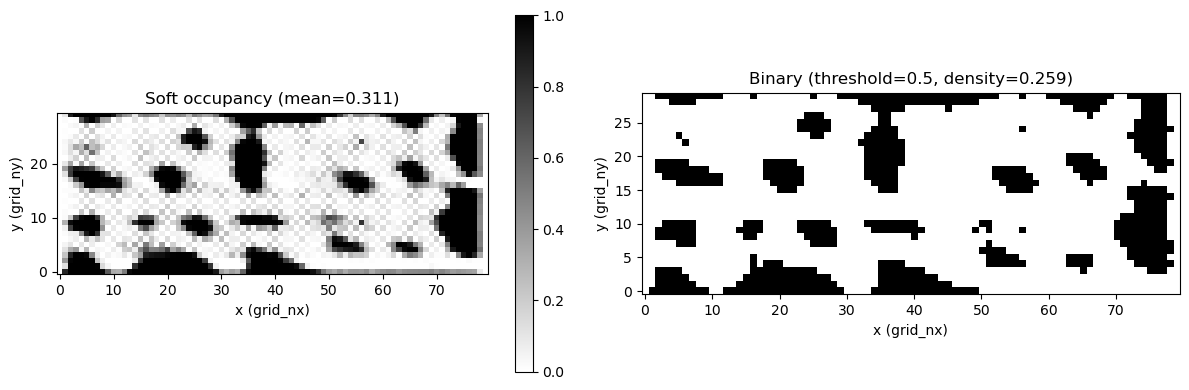

In [1042]:
# Initialize the HeatExchangerGenerator with desired parameters
hx_gen = HeatExchangerGenerator(
    grid_nx=80,
    grid_ny=30,
    domain_length=0.16,
    domain_height=0.06,
    latent_dim=32,
    threshold=0.5,
    device=device,
    min_density=0.15,
    max_density=0.80,
    mesh_params={
        "mesh_algorithm": 8,
        "mesh_recombine": 1,
        "mesh_element_order": 2
    }
)

# Pretrain the CNN to produce filter-valid designs using only the differentiable FilterLoss — no simulation required.
hx_gen.pretrain_on_filter(n_steps=3000, batch_size=16, lr=1e-3, log_every=100)

# Get an example geometry and run the diagnostic to visualize the CNN output and filter checks
hx_gen.run_diagnostic()

=== Raw CNN output stats ===
  shape:  (30, 80)
  min:    0.0000
  max:    1.0000
  mean:   0.4992

=== After threshold (0.5) ===
  solid density: 0.4596  (valid range: 0.15–0.8)
  density_ok:    True

=== Filter report ===
  solid_density: 0.4596
  density_ok: True
  has_flow_path: True
  no_enclosed_fluid: True
  valid: True


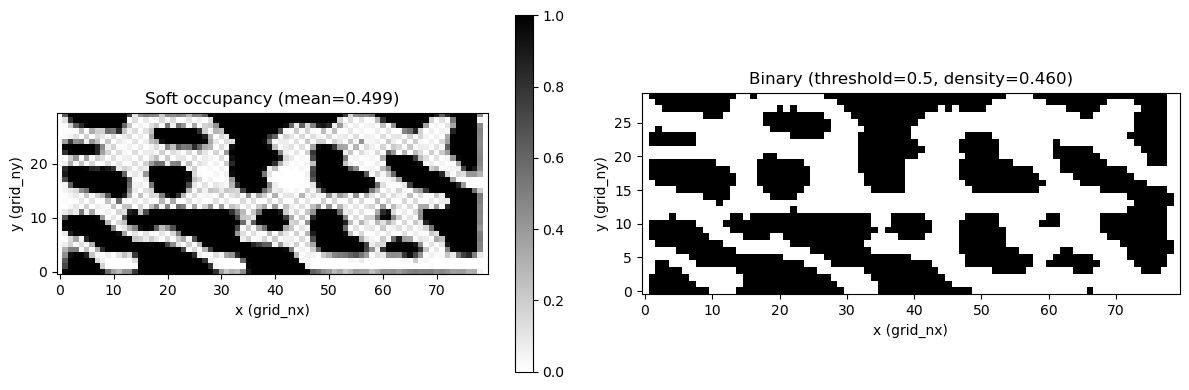

In [1084]:
hx_gen.run_diagnostic()

In [254]:
# -------------------------------------------------------------
# Heat Exchanger Simulator
# -------------------------------------------------------------

In [255]:
class Simulator:
    def __init__(self, type='MOOSE', params="./cutthroat-opt"):
        self.type = type
        if self.type == 'MOOSE':
            self.app_name = params
        else:
            pass

    def run_moose(self, input_file, n_processors=1):
        '''Run a MOOSE simulation inside a subprocess
        
        Parameters:
        input_file: str, path to the MOOSE input file (.i)
        n_processors: int, number of processors to use for the simulation
        '''
        # Construct the command to run MOOSE
        cmd = [
            "conda", "run", "-n", "moose",
            "mpiexec", "-np", str(n_processors),
            self.app_name, "-i", input_file
        ]

        # Run the command and capture the output
        result = subprocess.run(cmd, capture_output=True, text=True)

        # Check for errors
        if result.returncode != 0:
            print("Error running MOOSE:")
            print(result.stderr)
        else:
            print("MOOSE simulation completed successfully.")
            print(result.stdout)

    def analyze_exodus_results(self, exodus_file):
        # Placeholder for analyzing Exodus results
        # This function would read the Exodus file, extract relevant data, and perform analysis
        mesh = pv.read(exodus_file)
        print(mesh)
        print(mesh.array_names)
    
    def run(self, input_file, n_processors=4):
        if self.type == 'MOOSE':
            self.run_moose(input_file, n_processors)
        else:
            pass

In [256]:
MOOSE_sim = Simulator(type='MOOSE', params="./cutthroat-opt")